# Analysis and Visualization -- Overnight Stays

In [1]:
import pandas as pd
import geopandas as gpd 
import matplotlib.pyplot as plt
from pysal.viz import mapclassify
import numpy as np
import seaborn as sns

## Read in dataframe prepared in retrieval and pre-processing notebook

In [2]:
# read in accommodation data by municipality
iceland_overnight_df_geo = gpd.read_file('iceland_overnight_geo_df.geojson')

In [3]:
iceland_overnight_df_geo.head(1)

,municipality,nrsveitarfelags,stjornsyslusvaedi,nights,population,area_km2,stays_per_pop,stays_per_area,geometry
0,Akraneskaupstadur,3000,4,34131.0,8071,10.229906,4.228844,3336.394327,GEOMETRYCOLLECTION (POLYGON ((350015.715 42622...


In [4]:
len(iceland_overnight_df_geo)

62

<Axes: >

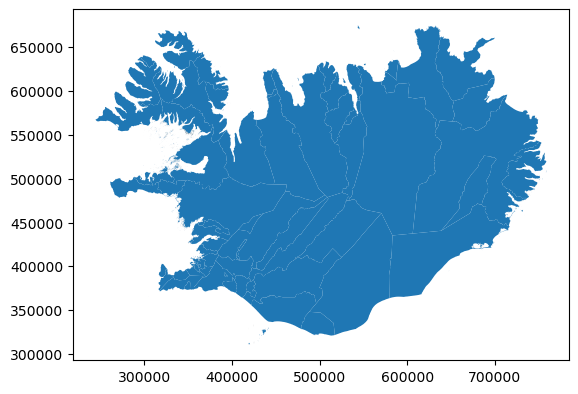

In [5]:
# check that everything looks good
iceland_overnight_df_geo.plot()

## Choropleth Maps

### look at distribution to decide on scheme

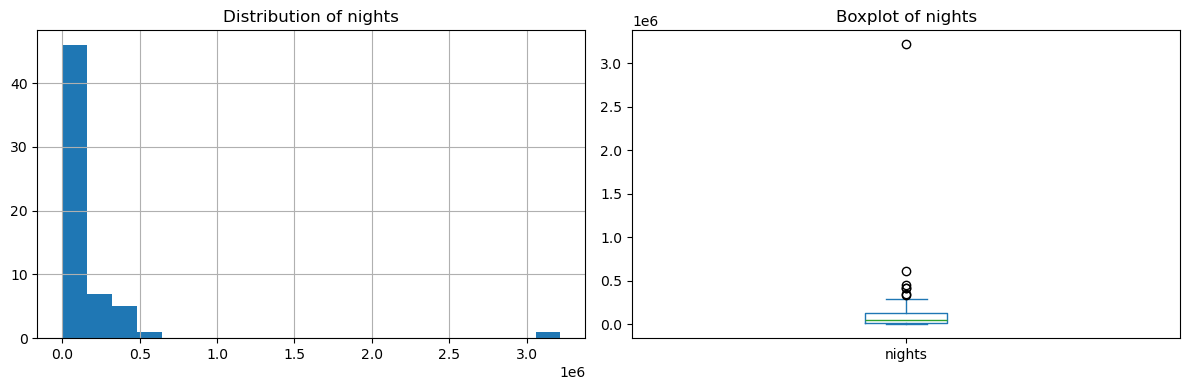

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

iceland_overnight_df_geo['nights'].hist(ax=axes[0], bins=20)
axes[0].set_title('Distribution of nights')

iceland_overnight_df_geo['nights'].plot(kind='box', ax=axes[1])
axes[1].set_title('Boxplot of nights')

plt.tight_layout()
plt.show()

In [7]:
print(iceland_overnight_df_geo['nights'].describe())

count    6.000000e+01
mean     1.552108e+05
std      4.238634e+05
min      3.880000e+02
25%      1.662000e+04
50%      4.502450e+04
75%      1.326788e+05
max      3.218190e+06
Name: nights, dtype: float64


The distribution is highly skewed. I will therefore use the Fisher Jenks scheme.

### Create the individual choropleth maps

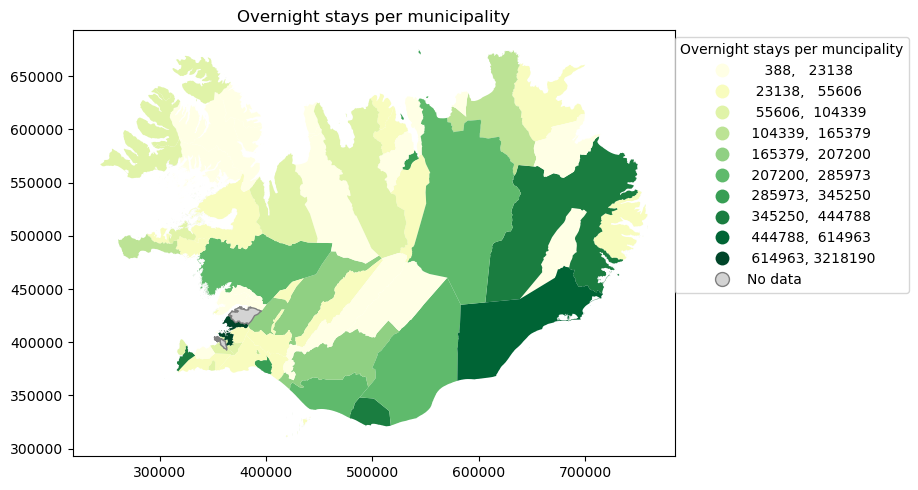

In [8]:
# map of absolute stays
fig, ax = plt.subplots(figsize=(10, 5))

iceland_overnight_df_geo.plot(
    column="nights", 
    scheme="fisher_jenks", 
    k=10,
    cmap="YlGn",
    legend=True,
    legend_kwds={"title": "Overnight stays per muncipality", "fmt": "{:.0f}"},
    missing_kwds={"color": "lightgrey", "edgecolor": "grey", "label": "No data"},
    ax=ax
);

# legend outside map box
ax.get_legend().set_bbox_to_anchor((1.4, 1))

plt.title("Overnight stays per municipality")
plt.tight_layout()
plt.show()

In [9]:
iceland_overnight_df_geo.nlargest(5, 'nights')

,municipality,nrsveitarfelags,stjornsyslusvaedi,nights,population,area_km2,stays_per_pop,stays_per_area,geometry
37,Reykjavikurborg,0,4,3218190.0,136894,244.194390,23.508627,13178.803966,GEOMETRYCOLLECTION (POLYGON ((354706.413 40602...
47,Sveitarfelagid Hornafjordur,8401,4,614963.0,2487,6309.523309,247.271009,97.465842,GEOMETRYCOLLECTION (POLYGON ((646723.221 39421...
31,Myrdalshreppur,8508,4,444788.0,881,749.097377,504.867196,593.765261,"MULTIPOLYGON (((493854.286 320826.840, 493849...."
30,Mulathing,7400,4,421237.0,5177,10669.159502,81.367008,39.481742,GEOMETRYCOLLECTION (POLYGON ((717360.513 45097...
36,Reykjanesbaer,2000,4,413463.0,21957,144.650641,18.830578,2858.355805,"MULTIPOLYGON (((304625.354 365840.317, 304629...."


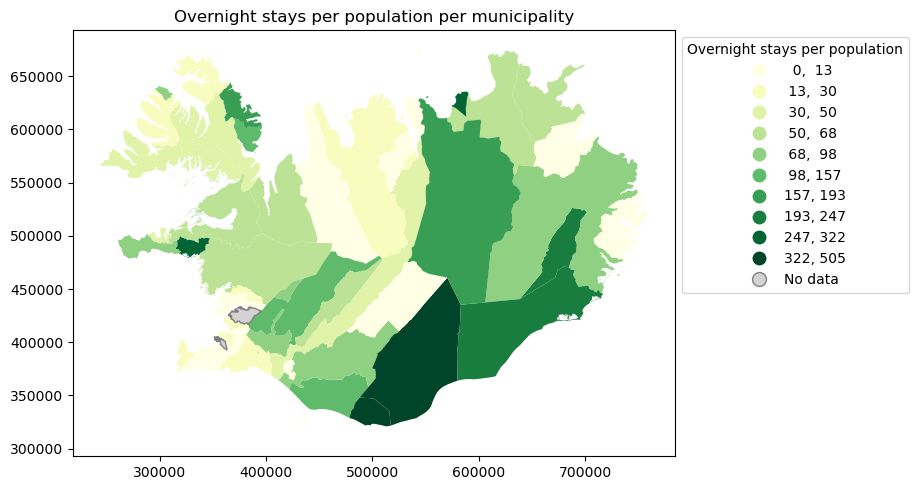

In [10]:
# per population
fig, ax = plt.subplots(figsize=(10, 5))

iceland_overnight_df_geo.plot(
    column="stays_per_pop",
    scheme="fisher_jenks",
    k=10,
    cmap="YlGn",
    legend=True,
    legend_kwds={"title": "Overnight stays per population", "fmt": "{:.0f}"},
    missing_kwds={"color": "lightgrey", "edgecolor": "grey", "label": "No data"},
    ax=ax
)

# legend outside map box
ax.get_legend().set_bbox_to_anchor((1.4, 1))

plt.title("Overnight stays per population per municipality")
plt.tight_layout()
plt.show()

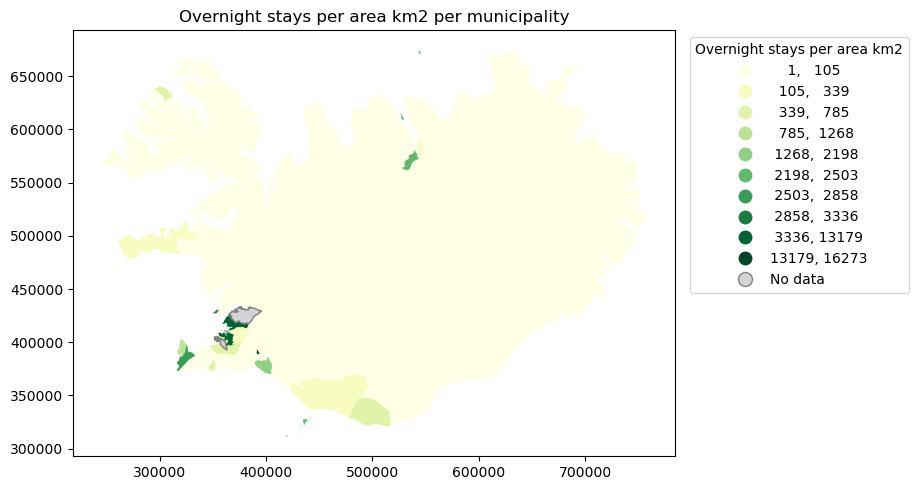

In [11]:
# per area
fig, ax = plt.subplots(figsize=(10, 5))

iceland_overnight_df_geo.plot(
    column="stays_per_area",
    scheme="fisher_jenks",
    k=10,
    cmap="YlGn",
    legend=True,
    legend_kwds={"title": "Overnight stays per area km2", "fmt": "{:.0f}"},
    missing_kwds={"color": "lightgrey", "edgecolor": "grey", "label": "No data"},
    ax=ax
)

# legend outside map box
ax.get_legend().set_bbox_to_anchor((1.4, 1))

plt.title("Overnight stays per area km2 per municipality")
plt.tight_layout()
plt.show()

### Create a combined figure

In [12]:
sum(iceland_overnight_df_geo['nights'].isna())

2

In [13]:
iceland_overnight_df_geo[iceland_overnight_df_geo["nights"].isna()]

,municipality,nrsveitarfelags,stjornsyslusvaedi,nights,population,area_km2,stays_per_pop,stays_per_area,geometry
13,Gardabaer,1300,4,NaN,19088,45.692698,NaN,NaN,GEOMETRYCOLLECTION (POLYGON ((358312.257 40321...
26,Kjosarhreppur,1606,4,NaN,269,284.366001,NaN,NaN,"MULTIPOLYGON (((385587.554 432938.670, 385581...."


In [14]:
# better for comparison and to be used in the report

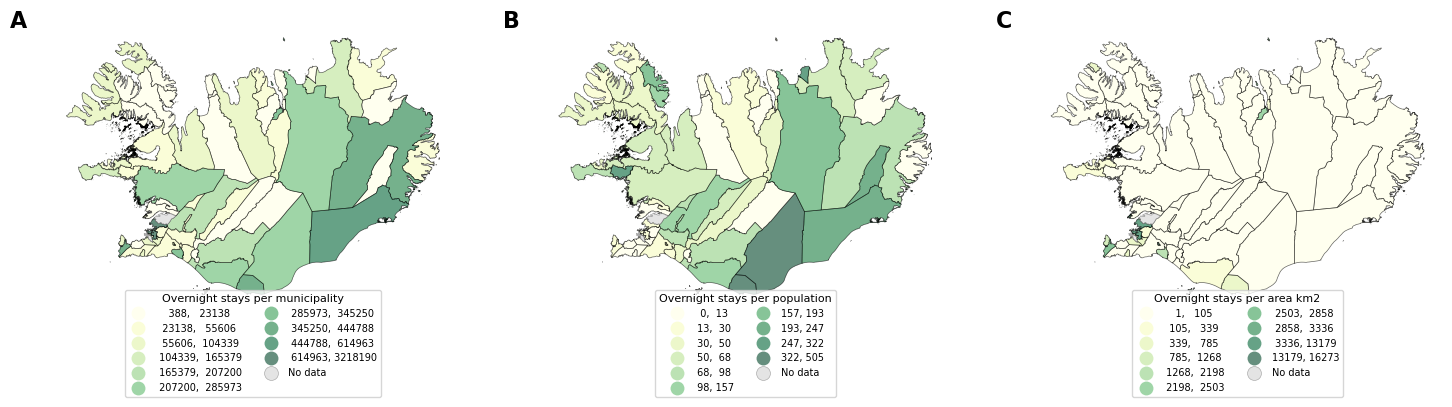

In [15]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(18, 9))

columns = ['nights', 'stays_per_pop', 'stays_per_area']
titles = ['Overnight stays per municipality', 'Overnight stays per population', 'Overnight stays per area km2']
labels = ['A', 'B', 'C']

for i, (col, title, label) in enumerate(zip(columns, titles, labels)):
    iceland_overnight_df_geo.plot(
        column=col,
        scheme='fisher_jenks',
        k=10,
        cmap='YlGn',
        legend=True,
        legend_kwds={
            'title': title,
            'fmt': '{:.0f}',
            'loc': 'lower center',
            'bbox_to_anchor': (0.5, -0.3),  # place legend below map to increase legibility
            'ncol': 2,                        
            'fontsize': 7,
            'title_fontsize': 8,
        },
        missing_kwds={"color": "lightgrey", "edgecolor": "grey", "label": "No data"},
        edgecolor='black',     
        linewidth=0.5,         
        alpha=0.6, 
        ax=ax[i]
    )

    ax[i].text(-0.05, 1.05, label, transform=ax[i].transAxes, 
               fontsize=16, fontweight='bold', va='top', ha='right')
    
    ax[i].set_axis_off()

plt.subplots_adjust(bottom=0.25)
plt.show()

### Inspect which scheme works the best

In [16]:
# this only works if there are no NaN values so I will remove them
fjenks10_nights = mapclassify.FisherJenks(
    iceland_overnight_df_geo["nights"].dropna(), 
    k=10)
headtail10_nights = mapclassify.HeadTailBreaks(
    iceland_overnight_df_geo["nights"].dropna())
eq10_nights = mapclassify.EqualInterval(
    iceland_overnight_df_geo["nights"].dropna(), 
    k=10)

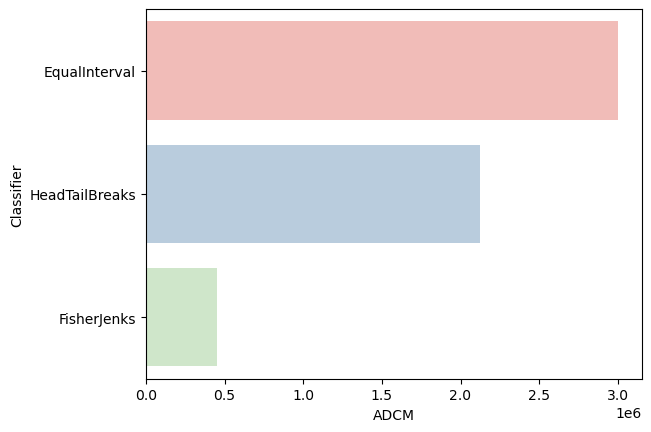

In [17]:
# Bunch classifier objects
classifiers = eq10_nights, headtail10_nights, fjenks10_nights
# Collect ADCM for each classifier
fits = np.array([c.adcm for c in classifiers])
# Convert ADCM scores to a DataFrame
adcms = pd.DataFrame(fits)
# Add classifier names
adcms["classifier"] = [c.name for c in classifiers]
# Add column names to the ADCM
adcms.columns = ["ADCM", "Classifier"]
ax = sns.barplot(
    y="Classifier", x="ADCM", data=adcms, palette="Pastel1", hue="Classifier", legend=False
)

This confirms that FisherJenks is the best choice out of the ones tested here.